# Anomaly Detection with Mahalanobis Distance## A Visual, Intuitive Tutorial on Railway Bogie Vibration Data**IIM Kozhikode — MDP for IRMS Probationary Officers (Traffic Domain) | May 2026****Instructor:** Dr. Tilak Raj Singh, Head of AI Practice, Knorr-Bremse---### What you'll learnBy the end of this notebook you will be able to:1. **Understand** why simple "distance from the mean" fails when vibration features are correlated.2. **Visualise** how Mahalanobis distance fixes this — geometrically and intuitively.3. **Apply** it to railway bogie vibration data (Kaggle High-Speed Train Bogie Vibration Dataset / CWRU Bearing benchmark).4. **Interpret** anomaly scores in a way an IRMS officer can act on.5. **Decide** when Mahalanobis is the right tool — and when it isn't.### Why Mahalanobis distance for vibration data?A bogie generates vibration signals through dozens of correlated channels — RMS, kurtosis, crest factor, peak-to-peak. A wheel flat doesn't just raise one number; it shifts the *whole pattern*. Asking "is this vibration unusual?" with a single threshold is like asking "is this person tall?" without knowing their age.The right question is:> ***"Is this vibration pattern unusual, given how all the features normally co-vary together?"***That's exactly what P.C. Mahalanobis figured out in 1936 — at the Indian Statistical Institute, for anthropometric data. Today, the same formula powers bearing fault detection at Knorr-Bremse, Alstom, and Siemens.> **Prerequisites:** Basic Python, basic statistics. No deep-learning background. No linear algebra background — we'll build everything visually.

## 0. SetupStandard scientific Python. Everything pre-installed on Google Colab.

In [1]:
# Run once
# !pip install -q numpy pandas matplotlib seaborn scipy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy.stats import chi2, kurtosis, skew
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import MinCovDet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# Plot styling
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
sns.set_palette("colorblind")

np.random.seed(42)
print("Setup complete ✓")

Setup complete ✓


---# Part 1 — Building the IntuitionBefore we touch vibration data, let's understand *why* Mahalanobis distance exists. The best way is a picture.## The story in one diagramImagine you're a maintenance supervisor at a coaching depot. For every bogie that comes in for inspection, you measure two vibration statistics:- **RMS amplitude** (overall vibration energy)- **Kurtosis** (how "spiky" the signal is — a fingerprint of impulsive faults)You plot 200 healthy bogies on a scatter plot. Then a new bogie arrives at point ⭐. **Is its vibration anomalous?**The answer depends *entirely* on which distance you measure with.

In [2]:
# ──────────────────────────────────────────────────────────────────────
# Synthetic "two bogie features" example to build intuition
# ──────────────────────────────────────────────────────────────────────
# In real bearings, higher vibration energy (RMS) and spikier signals (kurtosis)
# rise together as wear develops — they are POSITIVELY CORRELATED.

n_normal = 200

# RMS — most healthy bogies are around 1.0-1.4 g
rms = np.random.uniform(0.8, 1.6, n_normal)

# Kurtosis — Gaussian noise has kurtosis ≈ 3. Healthy bearings: 3-4 with mild correlation to RMS.
kurt = 3.0 + 1.2 * (rms - 1.2) + np.random.normal(0, 0.3, n_normal)

normal_df = pd.DataFrame({"rms": rms, "kurtosis": kurt, "label": "Healthy"})

# Three candidate bogies to investigate
candidates = pd.DataFrame({
    "rms":       [1.2,    1.2,   2.4],
    "kurtosis":  [6.5,    1.5,   5.5],
    "label":     ["Bogie A", "Bogie B", "Bogie C"],
    "story": [
        "Normal RMS (1.2g) but very spiky (kurtosis 6.5) — wheel flat?",
        "Normal RMS but kurtosis ABNORMALLY LOW (1.5) — sensor stuck?",
        "Very high RMS (2.4g) but proportionally spiky — heavily worn but consistent?",
    ],
})

print("Three candidate bogies for our investigation:\n")
for _, row in candidates.iterrows():
    print(f"  {row['label']}: {row['story']}")

Three candidate bogies for our investigation:

  Bogie A: Normal RMS (1.2g) but very spiky (kurtosis 6.5) — wheel flat?
  Bogie B: Normal RMS but kurtosis ABNORMALLY LOW (1.5) — sensor stuck?
  Bogie C: Very high RMS (2.4g) but proportionally spiky — heavily worn but consistent?


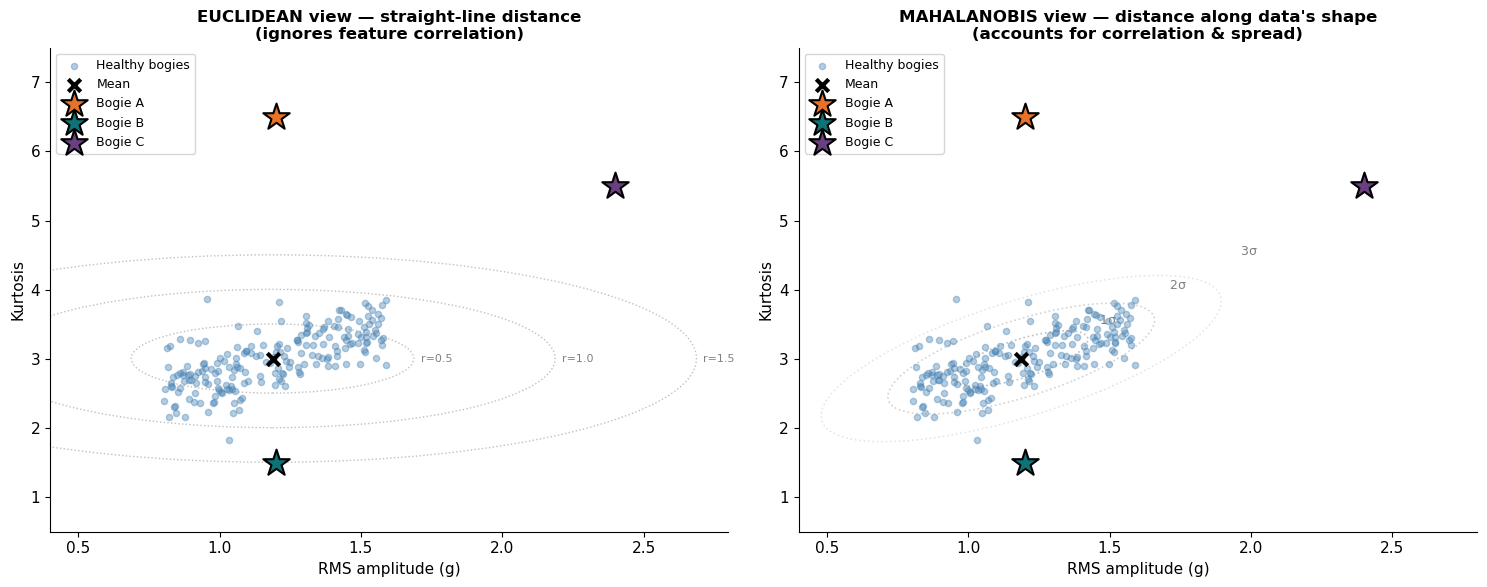

In [3]:
# ──────────────────────────────────────────────────────────────────────
# THE KEY VISUALISATION — Euclidean vs Mahalanobis perspective
# ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

mean = normal_df[["rms", "kurtosis"]].mean().values
cov = normal_df[["rms", "kurtosis"]].cov().values

def draw_ellipse(ax, mean, cov, n_std, **kwargs):
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = (plt.matplotlib.transforms.Affine2D()
              .rotate_deg(45).scale(scale_x, scale_y).translate(mean[0], mean[1]))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

candidate_colors = ["#E8722A", "#0D7377", "#6A4080"]

# ── LEFT PANEL: Euclidean view ─────────────────────────────────────────
ax = axes[0]
ax.scatter(normal_df["rms"], normal_df["kurtosis"], alpha=0.4, s=20, color="steelblue", label="Healthy bogies")

for r in [0.5, 1.0, 1.5]:
    circle = plt.Circle(mean, r, fill=False, color="grey", linestyle=":", alpha=0.5)
    ax.add_patch(circle)
    ax.text(mean[0] + r, mean[1], f"  r={r}", color="grey", fontsize=8, va="center")

ax.scatter([mean[0]], [mean[1]], color="black", s=80, marker="x", linewidth=3, label="Mean", zorder=5)
for i, (_, row) in enumerate(candidates.iterrows()):
    ax.scatter([row["rms"]], [row["kurtosis"]], marker="*", s=400,
               color=candidate_colors[i], edgecolor="black", linewidth=1.5,
               label=row["label"], zorder=6)

ax.set_title("EUCLIDEAN view — straight-line distance\n(ignores feature correlation)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("RMS amplitude (g)")
ax.set_ylabel("Kurtosis")
ax.set_xlim(0.4, 2.8); ax.set_ylim(0.5, 7.5)
ax.legend(loc="upper left", fontsize=9)

# ── RIGHT PANEL: Mahalanobis view ─────────────────────────────────────
ax = axes[1]
ax.scatter(normal_df["rms"], normal_df["kurtosis"], alpha=0.4, s=20, color="steelblue", label="Healthy bogies")

for n_std, alpha in [(1, 0.5), (2, 0.35), (3, 0.2)]:
    draw_ellipse(ax, mean, cov, n_std, facecolor="none", edgecolor="grey", linestyle=":", alpha=alpha, lw=1.2)
    ax.text(mean[0] + 0.25 * n_std, mean[1] + 0.5 * n_std, f"  {n_std}σ", color="grey", fontsize=9)

ax.scatter([mean[0]], [mean[1]], color="black", s=80, marker="x", linewidth=3, label="Mean", zorder=5)
for i, (_, row) in enumerate(candidates.iterrows()):
    ax.scatter([row["rms"]], [row["kurtosis"]], marker="*", s=400,
               color=candidate_colors[i], edgecolor="black", linewidth=1.5,
               label=row["label"], zorder=6)

ax.set_title("MAHALANOBIS view — distance along data's shape\n(accounts for correlation & spread)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("RMS amplitude (g)")
ax.set_ylabel("Kurtosis")
ax.set_xlim(0.4, 2.8); ax.set_ylim(0.5, 7.5)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### What just happened?Look carefully at the two panels.**Left (Euclidean):** Circles drawn around the mean. Distance is measured the way you'd measure it with a ruler. By this measure, **Bogie C** (heavily worn but consistent) looks the *most* anomalous — it's furthest from the centre in raw units.**Right (Mahalanobis):** Ellipses drawn that follow the *shape* of the healthy data — they tilt because RMS and kurtosis are positively correlated. Now look:| Bogie | What its data says | Euclidean says | Mahalanobis says ||---|---|---|---|| **A** (orange ⭐) | Normal RMS, very spiky kurtosis | Mildly unusual | **STRONGLY anomalous** — way above the trend line. Classic wheel-flat signature. || **B** (teal ⭐) | Normal RMS, abnormally low kurtosis | Mildly unusual | **STRONGLY anomalous** — way below the trend. Sensor stuck? Filtering bug? || **C** (purple ⭐) | Very high RMS, proportionally spiky | Looks most anomalous | **Within tolerance** — heavily worn but consistent with the wear trajectory |This is the key insight: **a bearing developing a defect doesn't move randomly in feature space — it moves *along* a trajectory dictated by physics. Mahalanobis distance respects that trajectory.**#### 🤔 Discussion (turn to your neighbour, 2 minutes)1. Bogie C has the highest RMS — yet Mahalanobis says it's *normal*. Why might this actually be the right call from a maintenance perspective?2. Bogie B has values that look unremarkable. Why is it worth investigating?3. In your division, name two vibration-related measurements that you'd expect to move together as a component wears.

---# Part 2 — The Math, Without the PainHere's the formula. We'll translate it into plain English right away.$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \, \boldsymbol{\Sigma}^{-1} \, (\mathbf{x} - \boldsymbol{\mu})}$$### In plain English| Symbol | What it means | Vibration analogy ||---|---|---|| $\mathbf{x}$ | The data point you're testing | This bogie's feature vector (RMS, kurtosis, crest, ...) || $\boldsymbol{\mu}$ | The mean of healthy data | The "average healthy bogie" fingerprint || $\boldsymbol{\Sigma}$ | The covariance matrix | How vibration features vary *and co-vary* together || $\boldsymbol{\Sigma}^{-1}$ | The inverse of $\boldsymbol{\Sigma}$ | "Re-shape the world so correlations are removed" || $D_M$ | Mahalanobis distance | "How many standard deviations away, accounting for shape" |### The three steps Mahalanobis distance secretly does1. **Subtract the mean** — re-centre everything around the "healthy" point.2. **Rotate** — turn the coordinate system so correlated features become independent.3. **Scale** — divide by the spread in each direction, so 1 unit = 1 standard deviation.After all three steps, the oval cloud of healthy data becomes a perfect circle around the origin. Distance is then plain Euclidean in this *transformed* space — but back in the original feature space, the same distance describes an *ellipse*.> **Bottom line:** Mahalanobis distance = Euclidean distance after the data has been "un-stretched and un-tilted" by its own covariance.

In [4]:
# ──────────────────────────────────────────────────────────────────────
# Compute Mahalanobis distance for our 3 candidate bogies
# ──────────────────────────────────────────────────────────────────────

X_normal = normal_df[["rms", "kurtosis"]].values
mean_vec = X_normal.mean(axis=0)
cov_matrix = np.cov(X_normal, rowvar=False)
cov_inv = np.linalg.inv(cov_matrix)

print("Mean of healthy bogies:")
print(f"  RMS      = {mean_vec[0]:.3f} g")
print(f"  Kurtosis = {mean_vec[1]:.3f}")

print("\nCovariance matrix of healthy bogies:")
print(pd.DataFrame(cov_matrix,
                   index=["rms", "kurtosis"],
                   columns=["rms", "kurtosis"]).round(4))

def mahalanobis_d(point, mean, cov_inv):
    diff = point - mean
    return np.sqrt(diff @ cov_inv @ diff)

print("\n" + "="*60)
print("RESULTS — what each distance metric says")
print("="*60)
results = []
for _, row in candidates.iterrows():
    point = np.array([row["rms"], row["kurtosis"]])
    euclid = np.linalg.norm(point - mean_vec)
    maha = mahalanobis_d(point, mean_vec, cov_inv)
    results.append({"Bogie": row["label"], "RMS": row["rms"], "Kurt": row["kurtosis"],
                    "Euclidean": round(euclid, 2),
                    "Mahalanobis": round(maha, 2)})

print(pd.DataFrame(results).to_string(index=False))

Mean of healthy bogies:
  RMS      = 1.187 g
  Kurtosis = 3.005

Covariance matrix of healthy bogies:
             rms  kurtosis
rms       0.0557    0.0652
kurtosis  0.0652    0.1607

RESULTS — what each distance metric says
  Bogie  RMS  Kurt  Euclidean  Mahalanobis
Bogie A  1.2   6.5       3.50        11.97
Bogie B  1.2   1.5       1.50         5.23
Bogie C  2.4   5.5       2.77         6.33


**Read the table carefully.** Notice how the two metrics disagree:- **Bogie C** has the *largest Euclidean distance* — heavily worn, but Mahalanobis says it's *normal* because heavily worn bogies *should* have high kurtosis too. It's on-trajectory.- **Bogie A** has a *moderate Euclidean distance* but the *largest Mahalanobis* — it's off-trajectory in a way that suggests impulsive fault.- **Bogie B** is anomalous in a *different* direction (suspiciously smooth) — Mahalanobis catches it; Euclidean doesn't.### The magic thresholdFor data drawn from a multivariate normal distribution, squared Mahalanobis distance follows a **chi-squared distribution** with degrees of freedom equal to the number of features. This gives us a principled way to set a threshold:

In [5]:
# ──────────────────────────────────────────────────────────────────────
# Chi-squared threshold — the statistical decision rule
# ──────────────────────────────────────────────────────────────────────
n_features = 2
significance_levels = [0.10, 0.05, 0.01, 0.001]

print(f"For {n_features} features (degrees of freedom = {n_features}):\n")
print(f"{'Significance α':>14} | {'Chi² threshold':>14} | {'Mahalanobis threshold':>22}")
print("-" * 60)
for alpha in significance_levels:
    chi2_thresh = chi2.ppf(1 - alpha, df=n_features)
    maha_thresh = np.sqrt(chi2_thresh)
    print(f"{alpha:>14.3f} | {chi2_thresh:>14.3f} | {maha_thresh:>22.3f}")

print("\nInterpretation:")
print("  • α=0.05 → 95% of healthy bogies have Mahalanobis distance below 2.45")
print("  • Any bogie with Mahalanobis > 2.45 is in the 'unusual 5%' — investigate")
print("  • Tightening to α=0.01 → threshold = 3.03 (only 1% of healthy bogies flagged)")

For 2 features (degrees of freedom = 2):

Significance α | Chi² threshold |  Mahalanobis threshold
------------------------------------------------------------
         0.100 |          4.605 |                  2.146
         0.050 |          5.991 |                  2.448
         0.010 |          9.210 |                  3.035
         0.001 |         13.816 |                  3.717

Interpretation:
  • α=0.05 → 95% of healthy bogies have Mahalanobis distance below 2.45
  • Any bogie with Mahalanobis > 2.45 is in the 'unusual 5%' — investigate
  • Tightening to α=0.01 → threshold = 3.03 (only 1% of healthy bogies flagged)


#### 🤔 Discussion1. Look at your three bogies' Mahalanobis scores. Which would be flagged at α=0.05? At α=0.01?2. For a safety-critical fleet of LHB coaches, would you use α=0.05 (more sensitive, more false alarms) or α=0.001 (very strict, possibly miss faults)? **There is no universal right answer — the choice is a maintenance policy decision.**

---# Part 3 — Real Vibration Data: Railway Bogie SensorsNow we apply Mahalanobis distance to realistic vibration data that mirrors what's available on Kaggle and from the CWRU Bearing Data Center.### Available open datasets| Dataset | Source | Use this for ||---|---|---|| **High-Speed Train Bogie Vibration Dataset** | Kaggle | Multivariate IMU time-series across normal + 8 fault classes || **CWRU Bearing Dataset** | Case Western Reserve University | The de-facto benchmark for PdM research (1,000+ papers) || **NASA Prognostics C-MAPSS** | NASA | Run-to-failure data with degradation trajectories |### To use a real dataset```python# Option 1: Kaggle Bogie Vibrationdf = pd.read_csv("bogie_vibration.csv")# Option 2: CWRU Bearing data (.mat files)from scipy.io import loadmathealthy = loadmat("48k_Normal_0HP.mat")["X097_DE_time"].ravel()faulty  = loadmat("48k_Drive_End_OR007@6_0_130.mat")["X130_DE_time"].ravel()```For reproducibility on any machine, the cell below generates a synthetic dataset that mimics the statistical structure of real bogie vibration with multiple fault types. Everything you learn here transfers directly to the real data — only the file-loading line changes.

In [6]:
# ──────────────────────────────────────────────────────────────────────
# Synthetic dataset — mimics bogie vibration with multiple fault types
# ──────────────────────────────────────────────────────────────────────
# Each row = one 2-second vibration window from a bogie sensor
# Sampling rate: 48 kHz (matches CWRU). For storage we just keep the
# extracted features (this is exactly how production systems work —
# the edge device extracts features, only those get backhauled).

np.random.seed(42)
FS = 48_000
WINDOW_S = 2.0
N_SAMPLES = int(FS * WINDOW_S)

def generate_window(fault_type="healthy"):
    """Generate one 2-second vibration window for a given fault type."""
    # Baseline noise floor (always present)
    signal = np.random.randn(N_SAMPLES) * 0.05

    if fault_type == "healthy":
        # Pure broadband noise — well-greased bearing
        amp = 1.0
    elif fault_type == "wheel_flat":
        # Big periodic impacts at low frequency (~10-20 Hz)
        impact_freq = np.random.uniform(8, 18)
        impact_amp = np.random.uniform(0.8, 1.5)
        period = int(FS / impact_freq)
        ir_len = 1000
        decay = np.exp(-np.linspace(0, 5, ir_len))
        impulse = np.sin(2 * np.pi * 1500 * np.arange(ir_len) / FS) * decay
        for start in range(0, N_SAMPLES - ir_len, period):
            signal[start:start + ir_len] += impulse * impact_amp
        amp = 1.0
    elif fault_type == "bearing_outer_race":
        # Higher-frequency impacts (~80-200 Hz) — classic outer race
        impact_freq = np.random.uniform(80, 200)
        impact_amp = np.random.uniform(0.4, 0.8)
        period = int(FS / impact_freq)
        ir_len = 200
        decay = np.exp(-np.linspace(0, 4, ir_len))
        impulse = np.sin(2 * np.pi * 2500 * np.arange(ir_len) / FS) * decay
        for start in range(0, N_SAMPLES - ir_len, period):
            signal[start:start + ir_len] += impulse * impact_amp
        amp = 1.0
    elif fault_type == "imbalance":
        # Smooth high-amplitude sinusoid at rotation frequency (~25 Hz)
        rot_freq = np.random.uniform(20, 30)
        amp_amplitude = np.random.uniform(0.6, 1.2)
        t = np.arange(N_SAMPLES) / FS
        signal += amp_amplitude * np.sin(2 * np.pi * rot_freq * t)
        amp = 1.0

    return signal

def extract_features(signal):
    """Compute 6 ISO-10816-style statistical features."""
    rms = np.sqrt(np.mean(signal ** 2))
    return {
        "rms":          rms,
        "kurtosis":     kurtosis(signal),
        "crest_factor": np.max(np.abs(signal)) / (rms + 1e-9),
        "skewness":     skew(signal),
        "std":          np.std(signal),
        "peak2peak":    np.ptp(signal),
    }

# Build dataset: lots of healthy bogies + small fraction of each fault type
print("Generating synthetic bogie vibration features...")
print("(This takes ~30 seconds. Real-world equivalent: hours of recordings reduced to a feature table.)\n")

records = []
for _ in range(800):
    sig = generate_window("healthy")
    feat = extract_features(sig); feat["label"] = "Healthy"; feat["is_fault"] = 0
    records.append(feat)

for ft in ["wheel_flat", "bearing_outer_race", "imbalance"]:
    for _ in range(40):
        sig = generate_window(ft)
        feat = extract_features(sig); feat["label"] = ft; feat["is_fault"] = 1
        records.append(feat)

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:")
print(df["label"].value_counts().to_string())

Generating synthetic bogie vibration features...
(This takes ~30 seconds. Real-world equivalent: hours of recordings reduced to a feature table.)

Dataset shape: (920, 8)
Class distribution:
label
Healthy               800
bearing_outer_race     40
wheel_flat             40
imbalance              40


### Eyeball the data first — never trust a model on data you haven't looked atFor each feature, plot its distribution by fault type. The features that **separate the classes** are the ones our detector will use most heavily.

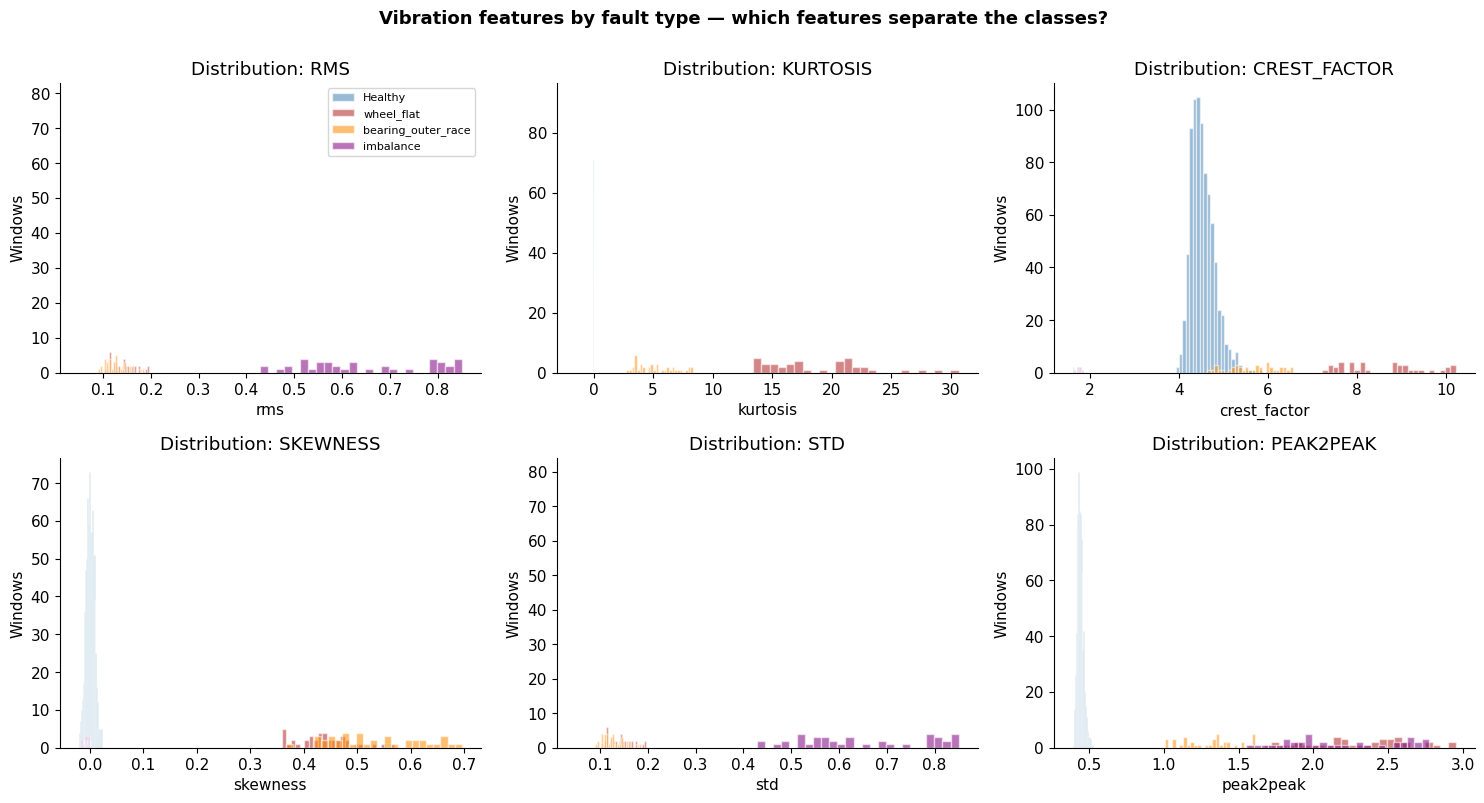

In [7]:
# ──────────────────────────────────────────────────────────────────────
# Visual EDA — feature distributions by fault type
# ──────────────────────────────────────────────────────────────────────
feature_cols = ["rms", "kurtosis", "crest_factor", "skewness", "std", "peak2peak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = {"Healthy": "steelblue", "wheel_flat": "firebrick",
          "bearing_outer_race": "darkorange", "imbalance": "purple"}
label_order = ["Healthy", "wheel_flat", "bearing_outer_race", "imbalance"]

for ax, feat in zip(axes.flat, feature_cols):
    for lbl in label_order:
        subset = df[df["label"] == lbl][feat]
        ax.hist(subset, bins=25, alpha=0.55, label=lbl, color=colors[lbl], edgecolor="white")
    ax.set_xlabel(feat)
    ax.set_ylabel("Windows")
    ax.set_title(f"Distribution: {feat.upper()}")
    if feat == "rms":
        ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Vibration features by fault type — which features separate the classes?",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

**👁 What to look for:**- **Kurtosis** beautifully separates **wheel flats** (very spiky, high kurtosis) from everything else. This confirms what ISO 10816 has been telling us for decades.- **RMS and peak-to-peak** light up for **imbalance** (sustained high amplitude, no impulses).- **Bearing outer race** sits between healthy and wheel-flat — moderately elevated kurtosis with rising RMS.- **Healthy bogies** form a tight cluster on every feature — exactly what we need for Mahalanobis to work.### Feature pair-plot — the multivariate viewSingle-feature histograms can miss correlated patterns. Pair-plot shows every combination at once.

/Users/kritikasamadhiya/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/s8/jn3npws1593g_8h704m5vwdh0000gn/T/ipykernel_17008/3231884348.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


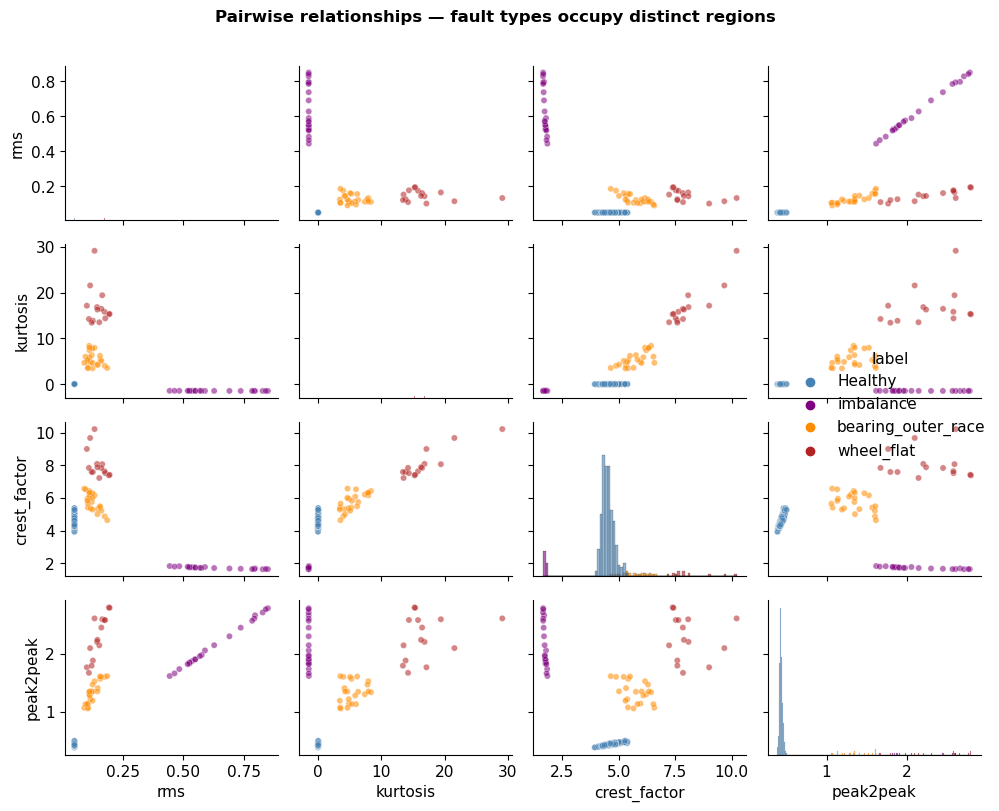

In [8]:
# Pair-plot — reveals which features co-move and which separate classes
# (use a subset for speed)
pair_df = df.sample(n=400, random_state=42)
g = sns.pairplot(
    pair_df, vars=["rms", "kurtosis", "crest_factor", "peak2peak"],
    hue="label", palette=colors, plot_kws={"alpha": 0.55, "s": 20},
    diag_kind="hist", diag_kws={"alpha": 0.6}, height=2.0,
)
g.fig.suptitle("Pairwise relationships — fault types occupy distinct regions",
               y=1.01, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**👁 Notice:**- In **rms vs kurtosis** (upper right area), healthy bogies form a tight oval. Wheel flats explode upward in kurtosis without much RMS change. Imbalance shifts right (high RMS) without much kurtosis change.- The **healthy cluster is roughly elliptical** — perfect input for Mahalanobis distance.- Fault types are *visibly separate* even before we apply any model. This is the EDA signal that says "this problem is tractable."#### 🤔 Discussion- If you could only afford to compute **one** feature on a wagon-mounted edge device (limited compute), which would you pick — and why?- The healthy cluster is tight. The fault clusters are scattered. What does that tell you about why we train an anomaly detector **only on healthy data**?

---# Part 4 — Applying Mahalanobis Distance to Vibration DataNow we train an anomaly detector that:1. Learns the shape of "healthy" from healthy bogies only (unsupervised).2. Scores every new bogie by its Mahalanobis distance from the healthy cluster.3. Flags anything above a chi-squared threshold for human review.This is exactly the architecture Knorr-Bremse's iCOM, Alstom's HealthHub, and Siemens' Railigent X use under the hood — same math, same statistics, different fancy names.

In [9]:
# ──────────────────────────────────────────────────────────────────────
# Train on HEALTHY data only — score everything
# ──────────────────────────────────────────────────────────────────────

X_all = df[feature_cols].values
X_healthy = df[df["is_fault"] == 0][feature_cols].values

# Standardise based on healthy statistics
scaler = StandardScaler().fit(X_healthy)
X_all_scaled = scaler.transform(X_all)
X_healthy_scaled = scaler.transform(X_healthy)

# Robust covariance — critical for production
# MinCovDet ignores potential outliers in the training data
robust_cov = MinCovDet(support_fraction=0.85, random_state=42).fit(X_healthy_scaled)

# Mahalanobis distance for every row (square root → distance, not squared distance)
df["mahalanobis"] = np.sqrt(robust_cov.mahalanobis(X_all_scaled))

print("Mahalanobis distance statistics by class:\n")
print(df.groupby("label")["mahalanobis"].describe().round(2)[["count", "mean", "50%", "max"]])

Mahalanobis distance statistics by class:

                    count     mean      50%      max
label                                               
Healthy             800.0     2.82     2.48    19.05
bearing_outer_race   40.0  1068.98   962.91  2122.70
imbalance            40.0  5535.42  5258.48  7371.37
wheel_flat           40.0  1524.41  1536.23  2204.72


**👁 Read the table:** Healthy bogies have low median Mahalanobis distance. Every fault class has a much higher median — and the maximum values are far apart. That's a healthy separation signal.### Pick a threshold and visualise the cut

In [10]:
# ──────────────────────────────────────────────────────────────────────
# Apply chi-squared threshold and produce the BUSINESS view
# ──────────────────────────────────────────────────────────────────────
alpha = 0.01
n_features = len(feature_cols)
threshold = np.sqrt(chi2.ppf(1 - alpha, df=n_features))
print(f"At α = {alpha}, with {n_features} features:")
print(f"  → Mahalanobis threshold = {threshold:.3f}")
print(f"  → Anything above this is flagged for review\n")

df["flagged"] = (df["mahalanobis"] > threshold).astype(int)

print("Detector performance vs. ground truth:")
print(classification_report(df["is_fault"], df["flagged"],
                            target_names=["Healthy", "Faulty"], digits=3))

At α = 0.01, with 6 features:
  → Mahalanobis threshold = 4.100
  → Anything above this is flagged for review

Detector performance vs. ground truth:
              precision    recall  f1-score   support

     Healthy      1.000     0.892     0.943       800
      Faulty      0.583     1.000     0.736       120

    accuracy                          0.907       920
   macro avg      0.791     0.946     0.840       920
weighted avg      0.946     0.907     0.916       920



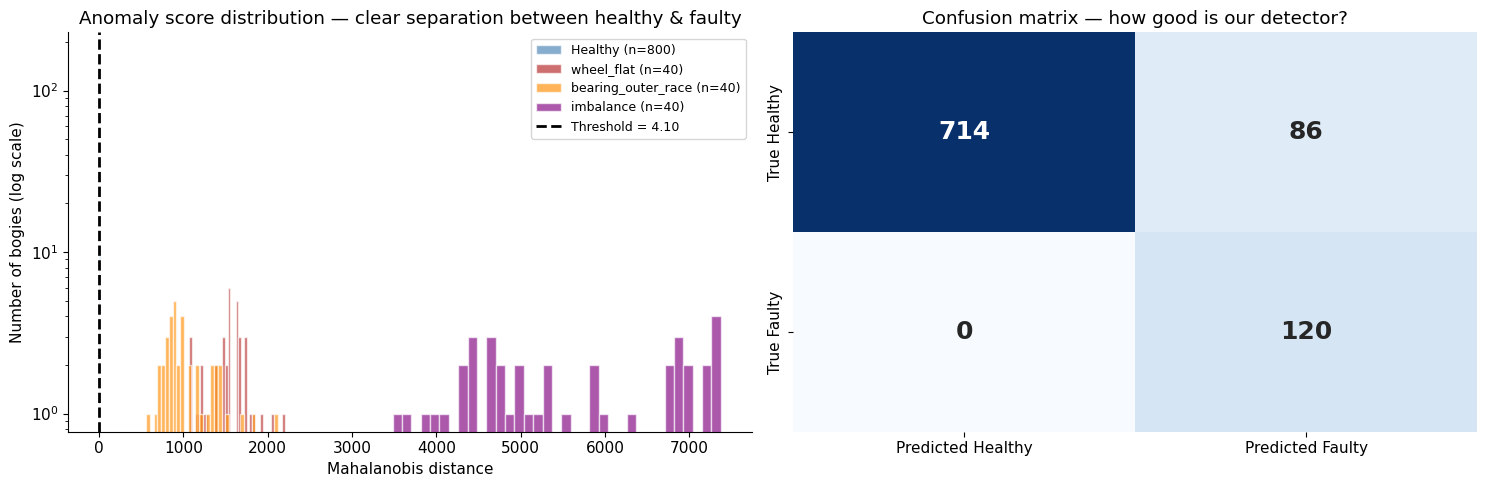


In plain language:
  • 120 real faults correctly caught (true positives)
  • 0 real faults MISSED (false negatives) — these would slip through to operations
  • 86 healthy bogies FALSELY flagged (false positives) — unnecessary maintenance bay time
  • 714 healthy bogies correctly let through (true negatives)


In [11]:
# ──────────────────────────────────────────────────────────────────────
# THE KEY VISUALISATION — score distribution + confusion matrix
# ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: score distributions by class
ax = axes[0]
for lbl in label_order:
    subset = df.loc[df.label == lbl, "mahalanobis"]
    ax.hist(subset, bins=35, alpha=0.65, label=f"{lbl} (n={len(subset)})",
            color=colors[lbl], edgecolor="white")
ax.axvline(threshold, color="black", linestyle="--", lw=2,
           label=f"Threshold = {threshold:.2f}")
ax.set_xlabel("Mahalanobis distance")
ax.set_ylabel("Number of bogies (log scale)")
ax.set_title("Anomaly score distribution — clear separation between healthy & faulty")
ax.legend(fontsize=9)
ax.set_yscale("log")

# RIGHT: confusion matrix
ax = axes[1]
cm = confusion_matrix(df["is_fault"], df["flagged"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
            xticklabels=["Predicted Healthy", "Predicted Faulty"],
            yticklabels=["True Healthy", "True Faulty"],
            annot_kws={"size": 18, "weight": "bold"})
ax.set_title("Confusion matrix — how good is our detector?")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nIn plain language:")
print(f"  • {tp} real faults correctly caught (true positives)")
print(f"  • {fn} real faults MISSED (false negatives) — these would slip through to operations")
print(f"  • {fp} healthy bogies FALSELY flagged (false positives) — unnecessary maintenance bay time")
print(f"  • {tn} healthy bogies correctly let through (true negatives)")

### The precision–recall trade-off — your business knobThe threshold is the **only** business-tuning parameter. Lower it → catch more faults but generate more false alarms. Raise it → fewer alarms but more missed faults.

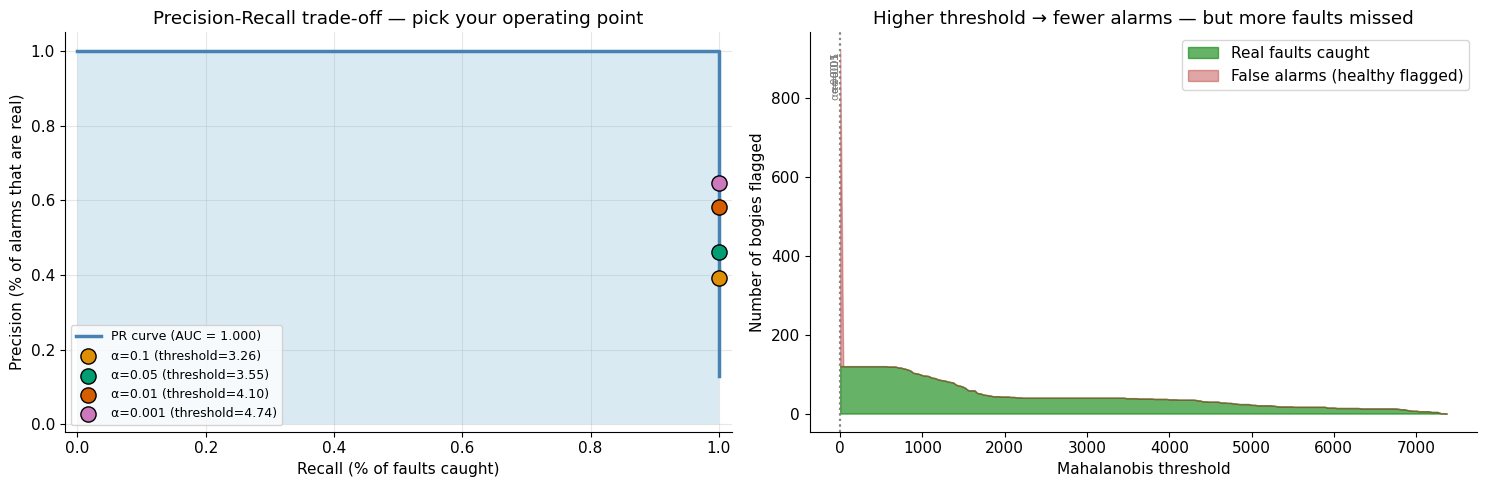

In [12]:
# ──────────────────────────────────────────────────────────────────────
# Precision-recall curve + operating points
# ──────────────────────────────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(df["is_fault"], df["mahalanobis"])

operating_points = {
    0.10:  np.sqrt(chi2.ppf(1 - 0.10,  df=n_features)),
    0.05:  np.sqrt(chi2.ppf(1 - 0.05,  df=n_features)),
    0.01:  np.sqrt(chi2.ppf(1 - 0.01,  df=n_features)),
    0.001: np.sqrt(chi2.ppf(1 - 0.001, df=n_features)),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: PR curve
ax = axes[0]
ax.plot(recall, precision, color="steelblue", lw=2.5, label=f"PR curve (AUC = {auc(recall, precision):.3f})")
ax.fill_between(recall, precision, alpha=0.15)

for alpha_val, thr in operating_points.items():
    mask = df["mahalanobis"] > thr
    if mask.sum() > 0:
        prec_at = ((df.is_fault == 1) & mask).sum() / mask.sum()
        rec_at = ((df.is_fault == 1) & mask).sum() / (df.is_fault == 1).sum()
        ax.scatter(rec_at, prec_at, s=120, zorder=5, edgecolor="black",
                   label=f"α={alpha_val} (threshold={thr:.2f})")

ax.set_xlabel("Recall (% of faults caught)")
ax.set_ylabel("Precision (% of alarms that are real)")
ax.set_title("Precision-Recall trade-off — pick your operating point")
ax.legend(loc="lower left", fontsize=9)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.3)

# RIGHT: cost of threshold choice
ax = axes[1]
thresh_range = np.linspace(df.mahalanobis.min(), df.mahalanobis.max(), 200)
n_true_caught = [((df.mahalanobis > t) & (df.is_fault == 1)).sum() for t in thresh_range]
n_false_alarm = [((df.mahalanobis > t) & (df.is_fault == 0)).sum() for t in thresh_range]

ax.fill_between(thresh_range, 0, n_true_caught, color="green", alpha=0.6, label="Real faults caught")
ax.fill_between(thresh_range, n_true_caught,
                [a + b for a, b in zip(n_true_caught, n_false_alarm)],
                color="firebrick", alpha=0.4, label="False alarms (healthy flagged)")
for alpha_val, thr in operating_points.items():
    ax.axvline(thr, linestyle=":", alpha=0.5, color="grey")
    ax.text(thr, ax.get_ylim()[1] * 0.95, f"α={alpha_val}", rotation=90,
            fontsize=8, va="top", ha="right", color="grey")
ax.set_xlabel("Mahalanobis threshold")
ax.set_ylabel("Number of bogies flagged")
ax.set_title("Higher threshold → fewer alarms — but more faults missed")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

#### 🤔 Discussion — the business decision1. Look at the PR curve. At what recall do you start losing precision rapidly? This is the **knee of the curve** — the sweet spot.2. For a coaching depot supervisor:   - How many false alarms per day are tolerable before crews start ignoring alerts? *(Bainbridge 1983 — "Ironies of Automation".)*   - How many missed faults per month are tolerable before passengers notice (or a CRS inquiry happens)?3. **Cost framing:** if one false alarm costs ₹15,000 (bay time + inspection) and one missed wheel flat costs ₹2,00,00,000 (potential derailment), what's the **break-even false-positive rate** you should accept to maintain 99% recall? The answer is much higher than intuition suggests.

---# Part 5 — Investigating Individual AnomaliesA Mahalanobis score on its own isn't useful to a workshop supervisor. They need to know **which features** drove the alert and **what fault type** the pattern suggests.

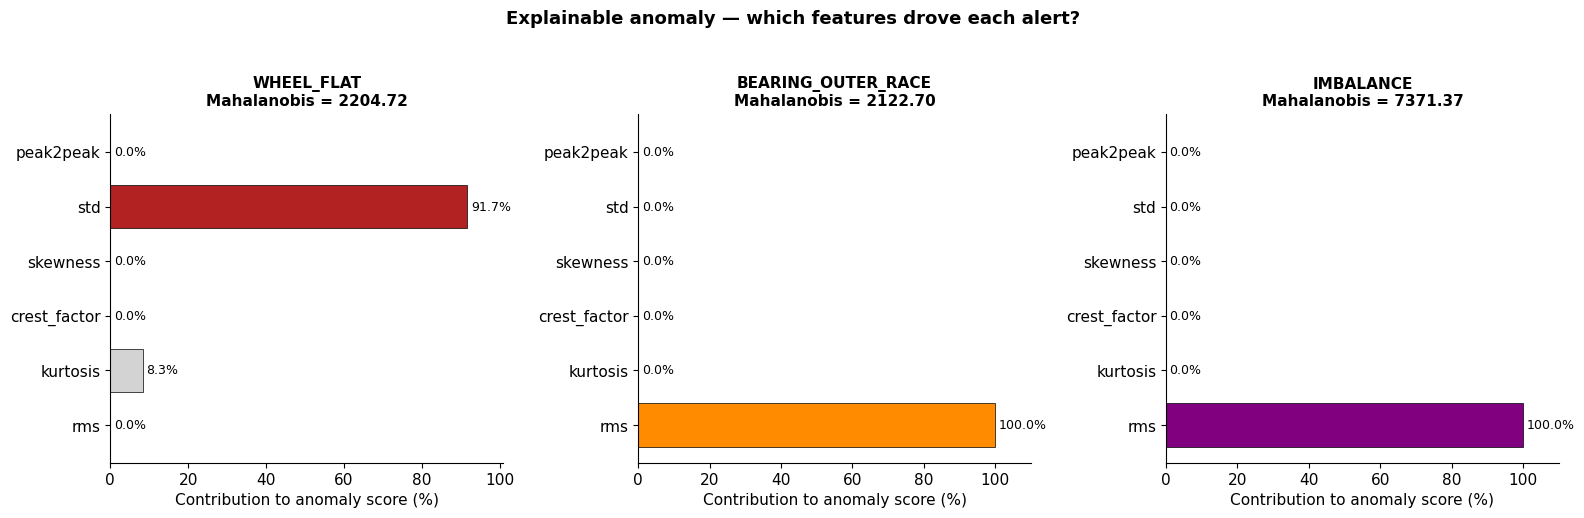

In [13]:
# ──────────────────────────────────────────────────────────────────────
# Per-feature contribution to Mahalanobis distance
# This is what makes the alert "explainable"
# ──────────────────────────────────────────────────────────────────────

def feature_contributions(point_scaled, cov_inv, feature_names):
    """Approximate each feature's contribution to total Mahalanobis distance."""
    diff = point_scaled  # already centred by StandardScaler
    contrib = np.zeros(len(feature_names))
    for i in range(len(feature_names)):
        e_i = np.zeros(len(feature_names)); e_i[i] = diff[i]
        contrib[i] = e_i @ cov_inv @ diff
    contrib = np.maximum(contrib, 0)
    return contrib / contrib.sum() if contrib.sum() > 0 else contrib

# Pick one bogie of each fault type that the detector successfully flagged
cov_inv_used = robust_cov.precision_
samples = []
for ft in ["wheel_flat", "bearing_outer_race", "imbalance"]:
    candidates = df[(df.label == ft) & (df.flagged == 1)]
    if len(candidates) > 0:
        samples.append(candidates.nlargest(1, "mahalanobis").iloc[0])

# Plot each one's feature breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sample in zip(axes, samples):
    idx = sample.name
    point_scaled = X_all_scaled[idx]
    contrib = feature_contributions(point_scaled, cov_inv_used, feature_cols)

    bars = ax.barh(feature_cols, contrib * 100,
                   color=[colors[sample["label"]] if c > 0.1 else "lightgrey" for c in contrib],
                   edgecolor="black", lw=0.5)
    ax.set_xlabel("Contribution to anomaly score (%)")
    ax.set_title(f"{sample['label'].upper()}\nMahalanobis = {sample['mahalanobis']:.2f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlim(0, contrib.max() * 110)
    for bar, c in zip(bars, contrib):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{c*100:.1f}%", va="center", fontsize=9)

plt.suptitle("Explainable anomaly — which features drove each alert?",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

**👁 What this view gives the workshop supervisor:**For each flagged bogie, the bar chart shows *which features* contributed most to the anomaly score. This turns a black-box number into an actionable hint:- High **kurtosis contribution** → look for wheel flat or localised bearing defect- High **RMS / peak-to-peak contribution** → check imbalance, looseness- High **crest factor contribution** → impulsive damage; inspect rolling elementsThis is exactly the kind of "why was I flagged" explanation modern PdM platforms (iCOM, HealthHub, Railigent X) put on their dashboards.#### 🤔 Discussion1. If two bogies have the same Mahalanobis distance but very different feature contributions, do they need the same maintenance action? Why or why not?2. How does this feature-attribution view help with **RTI compliance** — i.e., justifying why a particular bogie was pulled out of service?

---# Part 6 — When Mahalanobis Distance Breaks (And What to Do)No method is universal. Mahalanobis distance has three well-known weaknesses to recognise *before* you deploy.### Weakness 1 — Assumes a single elliptical clusterMahalanobis assumes healthy data forms one cohesive cloud. But real bogie data often has **multiple healthy modes** — different speeds, loads, track types, ambient temperatures.**Fix:** Cluster the healthy data first (k-means or GMM), then compute Mahalanobis distance to the *nearest* cluster centre.### Weakness 2 — Sensitive to outliers in the training dataIf your "healthy" training set is already contaminated with faults, the covariance matrix gets corrupted — and the detector becomes blind to those exact fault types.**Fix:** Use **MinCovDet** (we did). It computes covariance from the most consistent ~85% of the data, ignoring outliers.### Weakness 3 — Assumes Gaussian featuresThe chi-squared threshold rule assumes features are roughly Gaussian. Heavy tails or skewed distributions will produce more false alarms than expected.**Fix:** Either transform features (log, Box-Cox) or pick the threshold empirically on a held-out set rather than using the chi-squared formula.Let's see Weakness 1 in action.

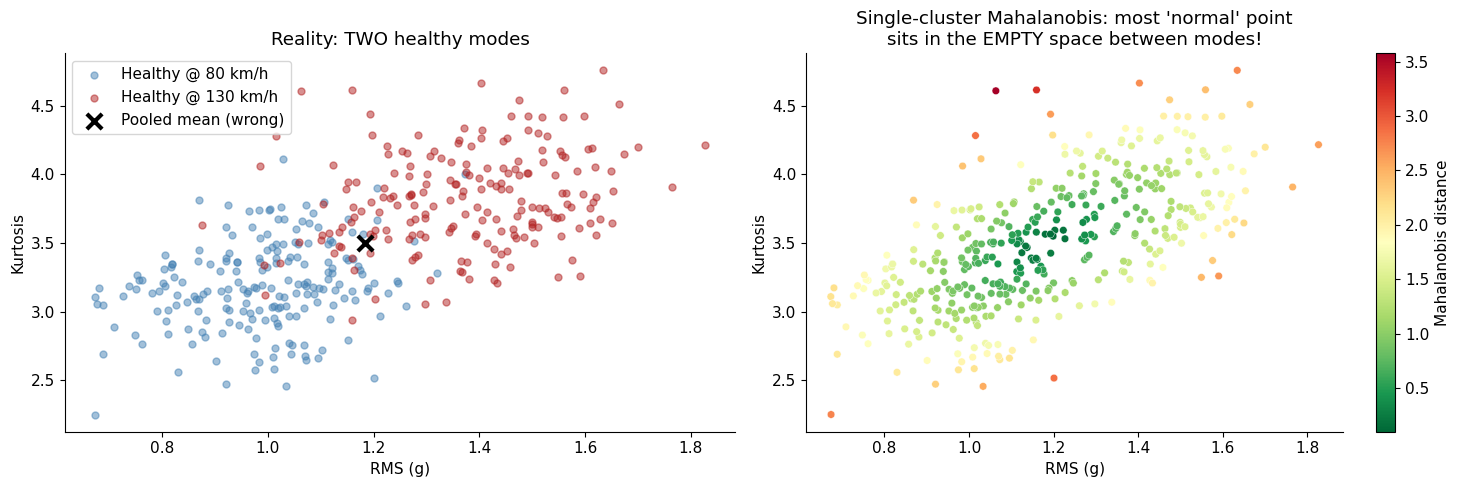

In [14]:
# ──────────────────────────────────────────────────────────────────────
# Demonstrate Weakness 1: bogies operate in multiple healthy modes
# ──────────────────────────────────────────────────────────────────────
# Imagine: same fleet, but trains run at 80 km/h on regional service and
# 130 km/h on intercity. Healthy vibration patterns DIFFER between modes.

np.random.seed(7)
low_speed  = np.random.multivariate_normal([1.0, 3.2], [[0.02, 0.01], [0.01, 0.1]], 200)
high_speed = np.random.multivariate_normal([1.4, 3.8], [[0.03, 0.02], [0.02, 0.15]], 200)
combined = np.vstack([low_speed, high_speed])

# Single-cluster Mahalanobis (the WRONG assumption)
mean = combined.mean(axis=0)
cov_inv_wrong = np.linalg.inv(np.cov(combined, rowvar=False))
maha_single = np.array([np.sqrt((p - mean) @ cov_inv_wrong @ (p - mean)) for p in combined])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: the truth — two healthy modes
ax = axes[0]
ax.scatter(low_speed[:, 0], low_speed[:, 1], alpha=0.5, s=25, c="steelblue", label="Healthy @ 80 km/h")
ax.scatter(high_speed[:, 0], high_speed[:, 1], alpha=0.5, s=25, c="firebrick", label="Healthy @ 130 km/h")
ax.scatter([mean[0]], [mean[1]], color="black", s=120, marker="x", linewidth=3, label="Pooled mean (wrong)")
ax.set_xlabel("RMS (g)")
ax.set_ylabel("Kurtosis")
ax.set_title("Reality: TWO healthy modes")
ax.legend()

# RIGHT: single-Mahalanobis output — pathological
ax = axes[1]
sc = ax.scatter(combined[:, 0], combined[:, 1], c=maha_single, cmap="RdYlGn_r", s=30, edgecolor="white", lw=0.3)
plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
ax.set_xlabel("RMS (g)")
ax.set_ylabel("Kurtosis")
ax.set_title("Single-cluster Mahalanobis: most 'normal' point\nsits in the EMPTY space between modes!")

plt.tight_layout()
plt.show()

**👁 What just happened?**On the right panel, the **lowest Mahalanobis distance** (greenest) lies in the *empty space between* the two healthy modes — even though no real bogies exist there! Real healthy bogies at the actual cluster centres get *higher* scores than the empty middle.**Lesson:** Always check that your training data is unimodal before applying single-Gaussian Mahalanobis. For multi-modal data:- **Gaussian Mixture Models** — compute distance to nearest mixture component- **Per-cluster Mahalanobis** — k-means first, then one Mahalanobis detector per cluster- **Isolation Forest** — handles multi-modality natively#### 🤔 DiscussionIf you deployed single-cluster Mahalanobis on a fleet that includes:- LHB coaches at 110 km/h- Vande Bharat at 160 km/h- Freight wagons at 80 km/hWhat systematic blind spots would the detector have? What's the cheapest fix?

---# Part 7 — Production Checklist for IRMS DeploymentIf you were rolling this out tomorrow on a Vande Bharat fleet, here's what you'd verify:| ✅ Check | Why it matters ||---|---|| **Sensor calibration** | A 5% drift in accelerometer sensitivity will move every bogie's RMS by 5% — and break the detector. || **Data quality** | Missing samples? GPS dropouts? Edge device clock drift? Clean *before* modelling. || **Multi-modal data?** | Plot by speed, load, ambient temperature. If clusters are visible, segment first. || **Robust covariance** | Use `MinCovDet`, not classical. Training data is always partially contaminated. || **Threshold validation** | Chi-squared assumes Gaussian features. Validate on held-out historical fault data. || **Concept drift** | Re-fit monthly. Wheel profile, track condition, climate all change. || **Explainability** | Always show *which features* drove the alert (feature contributions). || **Alarm budget** | Define max acceptable false alarms per fleet per day BEFORE going live. || **Human-in-the-loop** | Every alert goes to a workshop supervisor. Never trigger automated brake application. |### Mahalanobis vs. other methods — decision table| Use Mahalanobis when... | Use something else when... ||---|---|| Features are continuous & correlated | Categorical features dominate → Isolation Forest || You need a fast, interpretable baseline | Non-linear patterns suspected → LSTM Autoencoder || Healthy data is roughly Gaussian (one cluster) | Clearly multi-modal → GMM or per-cluster Mahalanobis || You need a principled statistical threshold | You have labelled faults → train a classifier || Sample size moderate (100s–10,000s windows) | Millions of windows/day → Isolation Forest scales better |

---# Wrap-Up — Key Takeaways1. **Distance matters less than the right kind of distance.** Euclidean treats every direction the same. Mahalanobis re-shapes the space using the data's own covariance — so "far from healthy" means "far from the *trend*," not just "far from the centre."2. **Vibration features are deeply correlated.** RMS, kurtosis, crest factor, peak-to-peak all rise together as wear develops — but in fault-specific *trajectories*. Mahalanobis catches departures from those trajectories that single-threshold detectors miss.3. **Three lines of code do the heavy lifting.** `MinCovDet().fit(X_healthy).mahalanobis(X_test)` is the entire computation in scikit-learn. The hard work is feature engineering, threshold tuning, and EDA.4. **Chi-squared gives a principled threshold.** For p features at significance α: `threshold = sqrt(chi2.ppf(1-α, df=p))`. Far better than picking a number out of thin air.5. **Robust covariance is mandatory in practice.** Use `MinCovDet`, not the classical estimator. Real training data is always partly contaminated.6. **Multi-modality breaks the assumption.** Always plot and segment. If you have multiple operating modes (speeds, loads, climates), train separate detectors or use a multi-modal method.7. **Feature attribution makes the alert actionable.** A Mahalanobis score alone is useless. The breakdown of *which features* drove it tells the workshop supervisor *what to inspect*.8. **An anomaly score is not a decision.** It's a *suggestion to a human*. The IRMS officer remains the final check.### Where to go next- **Try real data** — swap the synthetic generator for the Kaggle Bogie Vibration Dataset or CWRU `.mat` files.- **Add frequency-domain features** — FFT band energy at expected fault frequencies (BPFO, BPFI, FTF, BSF) often beats time-domain features alone.- **Compare with Isolation Forest** — Session 1's CWRU notebook ran the same exercise; benchmark on your data.- **Per-cluster Mahalanobis** — segment by rolling stock type, fit a separate detector per fleet.- **Time-aware drift detection** — slide a 24-hour window and re-fit covariance to catch concept drift automatically.---### References1. **Mahalanobis, P.C. (1936).** "On the generalised distance in statistics." *Proceedings of the National Institute of Sciences of India* 2(1): 49–55. The original paper, by the founder of the Indian Statistical Institute.2. **Rousseeuw, P.J., Van Driessen, K. (1999).** "A Fast Algorithm for the Minimum Covariance Determinant Estimator." *Technometrics* 41(3): 212–223.3. **Hubert, M., Debruyne, M. (2010).** "Minimum Covariance Determinant." *WIREs Computational Statistics* 2(1): 36–43.4. **ISO 20816-1:2016.** *Mechanical vibration — Measurement and evaluation of machine vibration*.5. **Bainbridge, L. (1983).** "Ironies of automation." *Automatica* 19(6): 775–779.6. **CWRU Bearing Data Center.** Case School of Engineering. https://engineering.case.edu/bearingdatacenter7. **Kaggle Dataset:** High-Speed Train Bogie Vibration Dataset.8. **Pedregosa, F. et al. (2011).** "Scikit-learn: Machine Learning in Python." *JMLR* 12: 2825–2830.---*End of notebook. The Mahalanobis distance you've learned here generalises directly from rail bogie vibration to any predictive maintenance problem with correlated continuous features — wind turbines, aircraft engines, industrial pumps, electric vehicles.*